In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/Final_Year_Project/Result/Datasets")

In [9]:
import pandas as pd
import numpy as np

In [11]:
import pandas as pd

# Load datasets
pd_data = pd.read_csv('Copy of combined_dataset_PD2.csv')  # Parkinson's Disease data
hc_data = pd.read_csv('Copy of combined_dataset_HC2.csv')  # Healthy Controls data

# Label datasets
pd_data['Label'] = 1  # Parkinson's Disease labeled as 1
hc_data['Label'] = 0  # Healthy Controls labeled as 0

# Combine datasets
combined_data = pd.concat([pd_data, hc_data], ignore_index=True)

# Drop columns that are completely empty
cleaned_data = combined_data.dropna(axis=1, how='all')

# Fill missing values and convert data types
for column in cleaned_data.columns:
    if cleaned_data[column].isnull().any():
        if cleaned_data[column].dtype in ['int64', 'float64']:  # Numeric columns
            if pd.api.types.is_integer_dtype(cleaned_data[column]):
                # Fill integer columns with median
                cleaned_data[column].fillna(cleaned_data[column].median(), inplace=True)
            else:
                # Fill float columns with mean
                cleaned_data[column].fillna(cleaned_data[column].mean(), inplace=True)
        else:
            # Fill categorical/object columns with mode
            cleaned_data[column].fillna(cleaned_data[column].mode()[0], inplace=True)

    # Attempt type conversion to integer
    if cleaned_data[column].dtype == 'float64':
        # Convert float columns to integers if possible
        if (cleaned_data[column] == cleaned_data[column].astype(int)).all():
            cleaned_data[column] = cleaned_data[column].astype(int)
    elif cleaned_data[column].dtype == 'object':
        # Attempt conversion of object columns to integers
        try:
            cleaned_data[column] = cleaned_data[column].astype(int)
        except ValueError:
            # Handle categorical columns by encoding
            cleaned_data[column] = cleaned_data[column].astype('category').cat.codes

# Save cleaned dataset
cleaned_data.to_csv('cleaned_combined_dataset.csv', index=False)

print("The cleaned dataset has been saved as 'cleaned_combined_dataset.csv'.")


<ipython-input-11-85bae5027bdb>:5: DtypeWarning: Columns (225,1385) have mixed types. Specify dtype option on import or set low_memory=False.
  hc_data = pd.read_csv('Copy of combined_dataset_HC2.csv')  # Healthy Controls data
<ipython-input-11-85bae5027bdb>:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_data[column].fillna(cleaned_data[column].mean(), inplace=True)
<ipython-input-11-85bae5027bdb>:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an in

The cleaned dataset has been saved as 'cleaned_combined_dataset.csv'.


In [17]:
dq = pd.read_csv('cleaned_combined_dataset.csv')
dq.tail(10)

,Filename,cA5_ChromaBin_10_kurtosis,cA5_ChromaBin_10_max,cA5_ChromaBin_10_mean,cA5_ChromaBin_10_min,cA5_ChromaBin_10_ptp,cA5_ChromaBin_10_skew,cA5_ChromaBin_10_std,cA5_ChromaBin_11_kurtosis,cA5_ChromaBin_11_max,...,cD5_SpectralRolloff_std,cD5_Tempo,cD5_ZeroCrossingRate_kurtosis,cD5_ZeroCrossingRate_max,cD5_ZeroCrossingRate_mean,cD5_ZeroCrossingRate_min,cD5_ZeroCrossingRate_ptp,cD5_ZeroCrossingRate_skew,cD5_ZeroCrossingRate_std,Label
1890,34,-1.500000,0.134106,0.097056,0.045390,0.088716,-0.523625,0.037663,-1.5,0.280580,...,726.619320,0,-1.5,0.336914,0.313477,0.266602,0.070312,-0.707107,0.033146,0
1891,48,-1.500000,0.290550,0.209473,0.131971,0.158579,0.082601,0.064789,-1.5,0.271011,...,425.367824,0,-1.5,0.319824,0.296549,0.250000,0.069824,-0.707107,0.032915,0
1892,43,-1.500000,0.297945,0.208290,0.134471,0.163473,0.338197,0.067671,-1.5,0.402673,...,186.068141,0,-1.5,0.355957,0.339193,0.305664,0.050293,-0.707107,0.023708,0
1893,42,-1.499999,0.160635,0.137647,0.120312,0.040323,0.463328,0.016940,-1.5,0.109332,...,315.167116,0,-1.5,0.322754,0.301432,0.258789,0.063965,-0.707107,0.030153,0
1894,44,-1.499999,0.067881,0.061603,0.057729,0.010152,0.650481,0.004480,-1.5,0.250395,...,202.763056,0,-1.5,0.333984,0.312337,0.269043,0.064941,-0.707107,0.030614,0
1895,8,-1.500000,0.187247,0.135393,0.101401,0.085846,0.608986,0.037253,-1.5,0.392352,...,512.693262,0,-1.5,0.345215,0.326335,0.288574,0.056641,-0.707107,0.026701,0
1896,1,-1.500000,0.098642,0.081134,0.067673,0.030968,0.437932,0.012963,-1.5,0.155540,...,315.657140,0,-1.5,0.328613,0.305827,0.260254,0.068359,-0.707107,0.032225,0
1897,41,-1.500000,0.192013,0.126797,0.041685,0.150328,-0.442448,0.062963,-1.5,0.554814,...,90.222722,0,-1.5,0.327637,0.308105,0.269043,0.058594,-0.707107,0.027621,0
1898,25,-1.500000,0.207026,0.183866,0.152219,0.054807,-0.500337,0.023165,-1.5,0.232845,...,296.467367,0,-1.5,0.330566,0.312663,0.276855,0.053711,-0.707107,0.025320,0
1899,0,-1.500000,0.591814,0.319749,0.141187,0.450627,0.608036,0.195488,-1.5,0.546427,...,180.445444,0,-1.5,0.326660,0.307780,0.270020,0.056641,-0.707107,0.026701,0


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Evaluation Metrics (in percentages):
Accuracy: 44.39%
Precision: 43.09%
Recall: 100.00%
F1 Score: 60.23%
Specificity: 3.94%
Geometric Mean: 19.85%


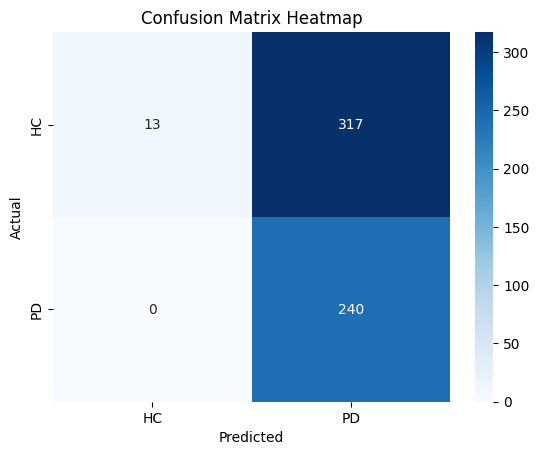

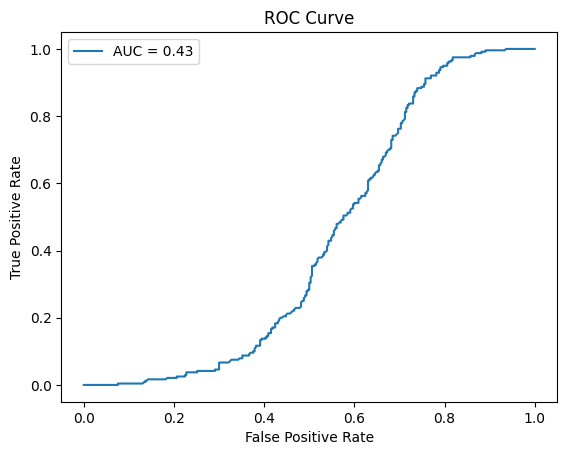

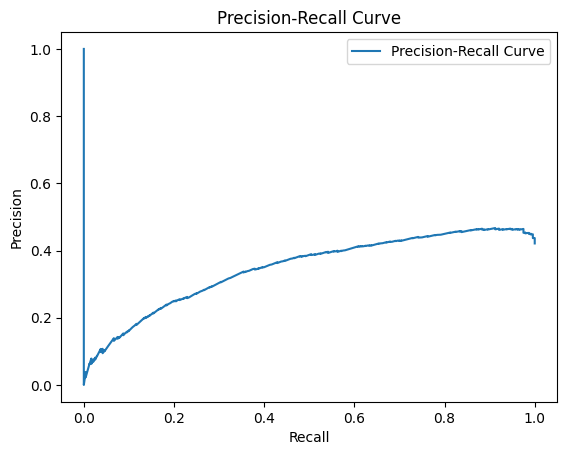

Optimal Threshold: 0.57
Evaluation with Optimal Threshold (in percentages):
Accuracy: 48.25%
Precision: 44.84%
Recall: 99.58%
F1 Score: 61.84%


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
)
from imblearn.combine import SMOTEENN
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
data = pd.read_csv('cleaned_combined_dataset.csv')

# Separate features and labels
X = data.drop(columns=['Label'])  # Features
y = data['Label']                # Target label

# Data Cleaning: Drop low-variance features
low_variance_threshold = 0.01
variance = X.var()
X = X.loc[:, variance > low_variance_threshold]

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X_scaled)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# Balance classes using SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_balanced, y_train_balanced = smote_enn.fit_resample(X_train, y_train)

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train_balanced, y_train_balanced)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predictions and evaluation
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
conf_matrix = confusion_matrix(y_test, y_pred)
specificity = (conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])) * 100
g_mean = np.sqrt((recall / 100) * (specificity / 100)) * 100

# Display evaluation metrics
print("Evaluation Metrics (in percentages):")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")
print(f"Specificity: {specificity:.2f}%")
print(f"Geometric Mean: {g_mean:.2f}%")

# Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall_vals, precision_vals, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Optimal Threshold Tuning
optimal_idx = np.argmax(precision_vals + recall_vals)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold:.2f}")

# Apply Optimal Threshold
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# Re-evaluate using the optimal threshold
accuracy_optimal = accuracy_score(y_test, y_pred_optimal) * 100
precision_optimal = precision_score(y_test, y_pred_optimal) * 100
recall_optimal = recall_score(y_test, y_pred_optimal) * 100
f1_optimal = f1_score(y_test, y_pred_optimal) * 100

print("Evaluation with Optimal Threshold (in percentages):")
print(f"Accuracy: {accuracy_optimal:.2f}%")
print(f"Precision: {precision_optimal:.2f}%")
print(f"Recall: {recall_optimal:.2f}%")
print(f"F1 Score: {f1_optimal:.2f}%")
